In [1]:
'''
    Code to plot p-values of variable interactions with logistic regression
    Supplemental Figures S6
'''

import pandas as pd
import numpy as np

import os 
from options.options import Options
import util.util as util
import util.bootstrap_tools as btool

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as plticker

opt = Options()
opt.initialize()

phen_labels = ['AFIB', 'CAD', 'T2D', 'HCA', 'AST', 'OB', 'MDD'] # List of phenotypes

covars = pd.read_csv(opt.env_file, sep='\t', index_col='IID')[opt.covars]
bounds, labels, label_map = util.create_bins_and_indices(covars, opt.bin_defs)

n = len(opt.covars)
n_context = n*(n+1)/2

In [3]:
# Determine significance in each two-way variable intersections
pval_zero = {}
pval_parent = {}
pval_zero_summary = np.full((len(phen_labels), n, n), 0)
pval_parent_summary = np.full((len(phen_labels), n, n), 0)

model_full = {}
model_high = {}
model_intx = {}
for i, phen in enumerate(phen_labels):
    pval_zero[phen] = np.load(f'results/{phen}/pval_zero.npy')
    pval_parent[phen] = np.load(f'results/{phen}/pval_parent.npy')

    model_full[phen] = np.load(f'results/{phen}/model_full.npy', allow_pickle=True).item()
    model_high[phen] = np.load(f'results/{phen}/model_high.npy', allow_pickle=True).item()

    #model_intx[phen] = np.load(f'results/{phen}/intx.npy', allow_pickle=True).item()

    pval_zero_ = pval_zero[phen]<.05/n_context
    pval_zero_summary[i] = pval_zero_
    pval_parent_summary[i] = pval_parent[phen]<.05

In [4]:
def significant_diff(model, i, j):
    w = model.params
    se = model.bse
    diff = w[i] - w[j]
    se_ij = (se[i]**2 + se[j]**2)**0.5
    from scipy.stats import norm
    z = diff / se_ij
    p = 2 * (1 - norm.cdf(abs(z)))
    return p

label_lookup = {c: [k for k, v in enumerate(labels) if c in v] for c in opt.covars}

pval_zero_full = {}
pval_zero_high = {}

for i_phen, phen in enumerate(phen_labels):
    pval_zero_high[phen] = np.full((n,n), np.nan)
    pval_zero_full[phen] = np.full((n,n), np.nan)
    for i in range(len(opt.covars)):
        ci = opt.covars[i]
        ci_idx = label_lookup[ci]
    
        ni = len(ci_idx)
        n_strata = ni
    
        key = f"{ci}"
        model_high_ = model_high[phen][key]
        model_full_ = model_full[phen][key]
    
        idx_max = model_full_.params[:n_strata].argmax()
        idx_min = model_full_.params[:n_strata].argmin()
        pval_zero_full[phen][i,i] = significant_diff(model_full_, idx_min, idx_max)
    
        idx_max = model_high_.params[:n_strata].argmax()
        idx_min = model_high_.params[:n_strata].argmin()
        pval_zero_high[phen][i,i] = significant_diff(model_high_, idx_min, idx_max)

        for j in range(i + 1, len(opt.covars)):
            cj = opt.covars[j]
            cj_idx = label_lookup[cj]
            
            ni = len(ci_idx)
            nj = len(cj_idx)
            n_strata = ni * nj
           
            key = f"{ci}_{cj}"
            model_high_ = model_high[phen][key]
            model_full_ = model_full[phen][key]
        
            idx_max = model_full_.params[:n_strata].argmax()
            idx_min = model_full_.params[:n_strata].argmin()
            pval_zero_full[phen][i,j] = pval_zero_full[phen][j,i] = significant_diff(model_full_, idx_min, idx_max)
        
            idx_max = model_high_.params[:n_strata].argmax()
            idx_min = model_high_.params[:n_strata].argmin()
            pval_zero_high[phen][i,j] = pval_zero_high[phen][j,i] = significant_diff(model_high_, idx_min, idx_max)

            

# Illustrate correlations in p-values

/tmp/ipykernel_792710/168201501.py:14: RuntimeWarning: divide by zero encountered in log10
  alt_pvals_one_log = -np.log10(alt_pvals_one)


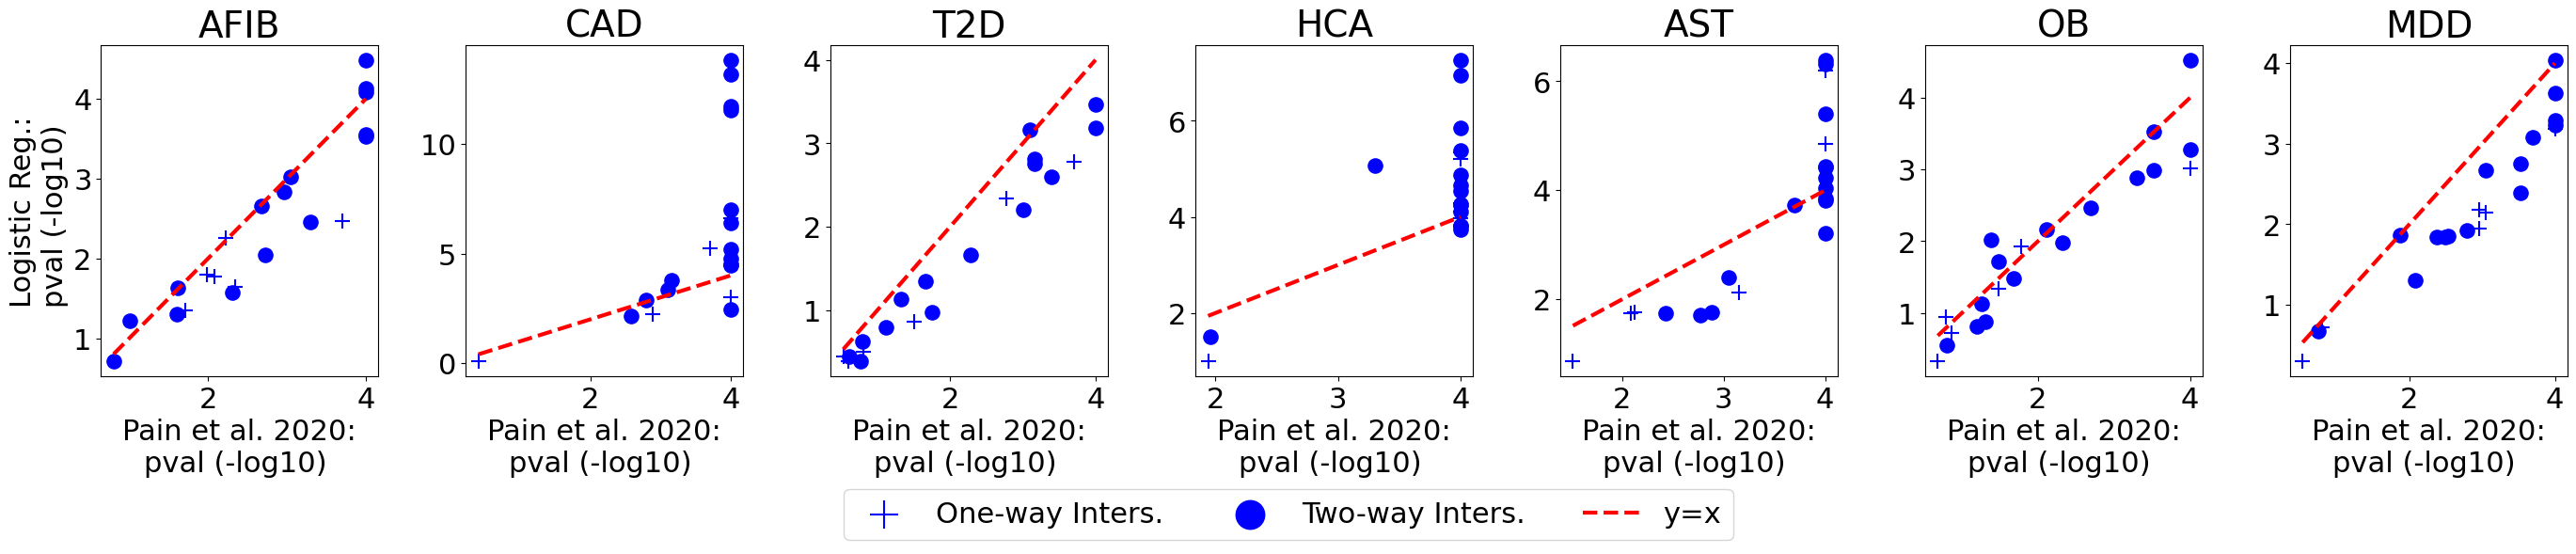

In [5]:
pval_thresh = .05/21
thr = -np.log10(pval_thresh)

fig, axes = plt.subplots(1, len(phen_labels), figsize=(4.5 * len(phen_labels)-4, 6))

for i, (ax, phen) in enumerate(zip(axes, phen_labels)):
    org_pvals_one = util.extract_1way_interactions(pval_zero[phen])
    alt_pvals_one = util.extract_1way_interactions(pval_zero_full[phen])

    org_pvals_two = util.extract_2way_interactions(pval_zero[phen])
    alt_pvals_two = util.extract_2way_interactions(pval_zero_full[phen])

    org_pvals_one_log = -np.log10(org_pvals_one)
    alt_pvals_one_log = -np.log10(alt_pvals_one)

    org_pvals_two_log = -np.log10(org_pvals_two)
    alt_pvals_two_log = -np.log10(alt_pvals_two)

    ax.scatter(org_pvals_one_log, alt_pvals_one_log, marker='+', color='blue', s=120, label='One-way Inters.')
    ax.scatter(org_pvals_two_log, alt_pvals_two_log, marker='o', color='blue', s=120, label='Two-way Inters.')

    mn = min(org_pvals_one_log.min(), org_pvals_two_log.min())
    mx = max(org_pvals_one_log.max(), org_pvals_two_log.max())

    ax.plot([mn, mx], [mn, mx], color='red', linestyle='--', label='y=x', linewidth=3)

    ax.set_title(phen, fontsize=28)
    ax.set_xlabel('Pain et al. 2020:\npval (-log10) ', fontsize=22)

    if i == 0:
        ax.set_ylabel('Logistic Reg.:\npval (-log10) ', fontsize=22)
    else:
        ax.set_ylabel('')

    ax.tick_params(axis='both', labelsize=22)

handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc='lower center', ncol=3, fontsize=22, markerscale=2)

plt.subplots_adjust(wspace=-1.1)
plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.savefig("pval_comp.png", dpi=150, bbox_inches="tight")

# Illustrate intersections with overlapping significance

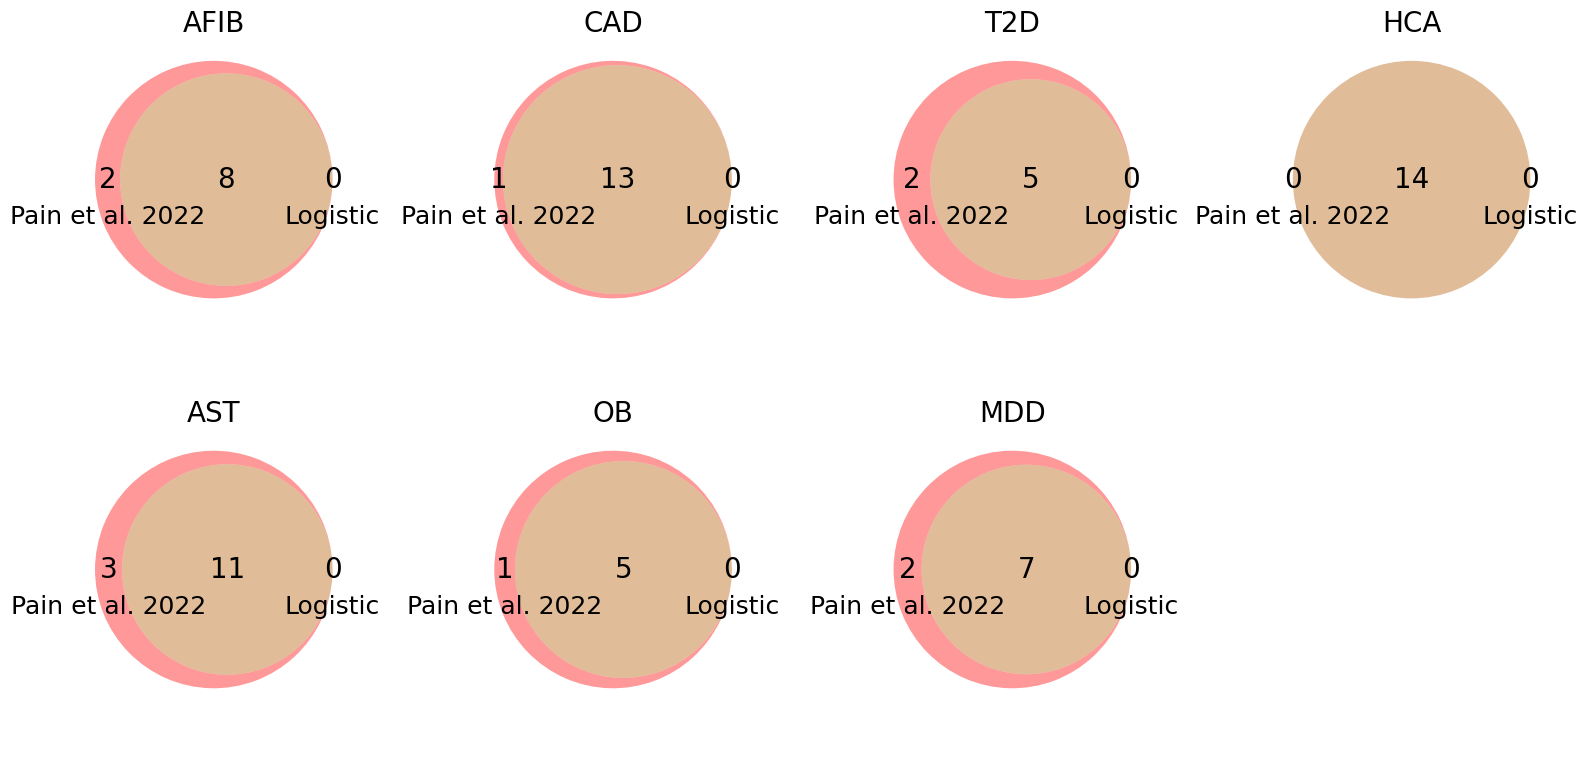

In [7]:
from matplotlib_venn import venn2
import math

cut_off = .05/21
n = len(phen_labels)
rows = 2
cols = math.ceil(n / 2)

fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 8))
axes = axes.flatten()

venn_labels = ['Pain et al. 2022', 'Logistic', '']
for i, phen in enumerate(phen_labels):
    org_pvals = util.extract_2way_interactions(pval_zero[phen]) < cut_off
    alt_pvals = util.extract_2way_interactions(pval_zero_full[phen]) < cut_off

    plt.sca(axes[i])
    v = venn2(
        subsets=(
            sum(org_pvals & ~alt_pvals),
            sum(~org_pvals & alt_pvals),
            sum(org_pvals & alt_pvals)
        ),
        set_labels=('', '')
    )

    for j, label in enumerate(v.subset_labels):
        if label:
            x, y = label.get_position()
            label.set_fontsize(20)
            axes[i].text(
                x,
                y - 0.12,
                venn_labels[j],
                ha='center',
                va='top',
                fontsize=18
            )

    axes[i].set_title(phen, fontsize=20)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig("insect_comp.png", dpi=150, bbox_inches="tight")